# 36 — Structure learning, in the paper's figure language

**Why this notebook exists (Plan P7 + output style).** Two things at once. First, **active
structure learning**: the paper's engine is *expansion* (entertain a new coupling, a real
inversion) and *reduction* (prune by closed-form Bayesian Model Reduction). On the relational
substrate (nb30) the data *expand* the net — the mass-balance experiment deposits new belt
couplings, so the edge count rises — and BMR *reduces* it, pruning the prior couplings the
data stop supporting. Second, we render the whole structural story in the **five figure types**
of `src/structural/plot.py` — the log-evidence race, the mean-field share, the Bayes-net
snapshots (the paradigm *as a network*, evolving), the edge-edit timeline, and the
community-distance heatmap — saved to `results/` for reuse.

Everything here is the principled phlogiston↔oxygen model on the relational substrate; the
world flips from the phlogiston regime to the oxygen regime at `t_shift`, and we watch the
paradigm — and its *structure* — follow.

In [1]:
%matplotlib inline
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax
import matplotlib.pyplot as plt

from src.config import NetworkConfig
from src.structural.phlogiston import StructuralConfig
from src.structural import step as S, shells, plot, observables as obs
from src.structural.agent import evidence_race
from src.structural import bmr, phlogiston as ph

RESULTS = pathlib.Path(ROOT if (ROOT / 'results').exists() else ROOT.parent) / 'results' / 'structural_paradigm_shift_relational'
RESULTS.mkdir(parents=True, exist_ok=True)
KEY = jax.random.PRNGKey(0)

# the headline scenario: relational substrate (edges learn), world flips phlogiston->oxygen at t=40
cfg = StructuralConfig(n_agents=120, n_steps=120, t_shift=40, observation_operator='relational',
                       precision_mode='derived', core_governance=0.0)
print('scenario:', cfg.observation_operator, 'substrate · regime shift at t =', cfg.t_shift)
print('saving figures to', RESULTS)

scenario: relational substrate · regime shift at t = 40
saving figures to C:\GitHub\Paradigm_Shift_Act_Inf\results\structural_paradigm_shift_relational


## 1 — Log-evidence race across paradigms

A single agent accumulates the regime-switching data; for each candidate paradigm we track the
running model log-evidence (`agent.evidence_race`). Phlogiston leads while the early
combustion data favour its common-cause prior; once the gravimetric (oxygen-regime) data
arrive after `t_shift`, oxygen's prior fits better and the upper envelope crosses — the
paradigm shift, read off the evidence.

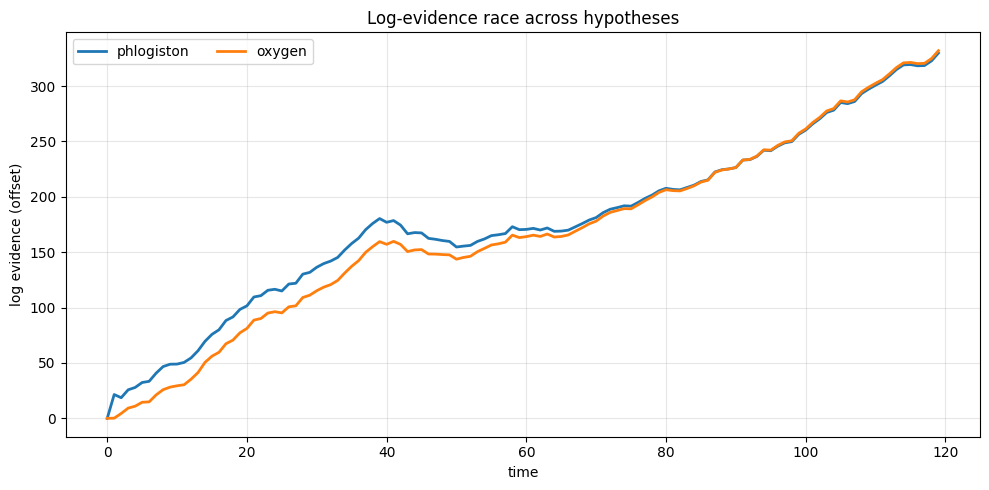

evidence gap (oxygen-phlogiston): t=40 -> -17.0 (phlogiston leads in its regime), t=end -> +5.0 (oxygen wins)
oxygen takes the lead for good at step 72 (regime shift at 40).


In [2]:
race = evidence_race(cfg, KEY)
logZ = np.stack([np.asarray(race['logZ_phlog']), np.asarray(race['logZ_oxy'])], axis=1)  # (T,2)
out = plot.plot_log_evidence_race(logZ, hypothesis_names=['phlogiston', 'oxygen'],
                                  save_path=RESULTS / 'log_evidence_race.png')
plt.show()
gap = logZ[:, 1] - logZ[:, 0]                                # oxygen - phlogiston
# the durable crossing: first step AFTER the regime shift where oxygen takes the lead for good
post = np.arange(cfg.t_shift, cfg.n_steps)
lead = post[gap[post] > 0]
cross = int(lead[0]) if lead.size else -1
print(f'evidence gap (oxygen-phlogiston): t={cfg.t_shift} -> {gap[cfg.t_shift]:+.1f} (phlogiston leads in its regime), '
      f't=end -> {gap[-1]:+.1f} (oxygen wins)')
print(f'oxygen takes the lead for good at step {cross} (regime shift at {cfg.t_shift}).')

## 2 — Mean-field hypothesis share

The population view: each agent's held paradigm (oxygen index above ½ ⇒ oxygen) over time,
as a stacked share. The community converts from phlogiston to oxygen after the regime flip.

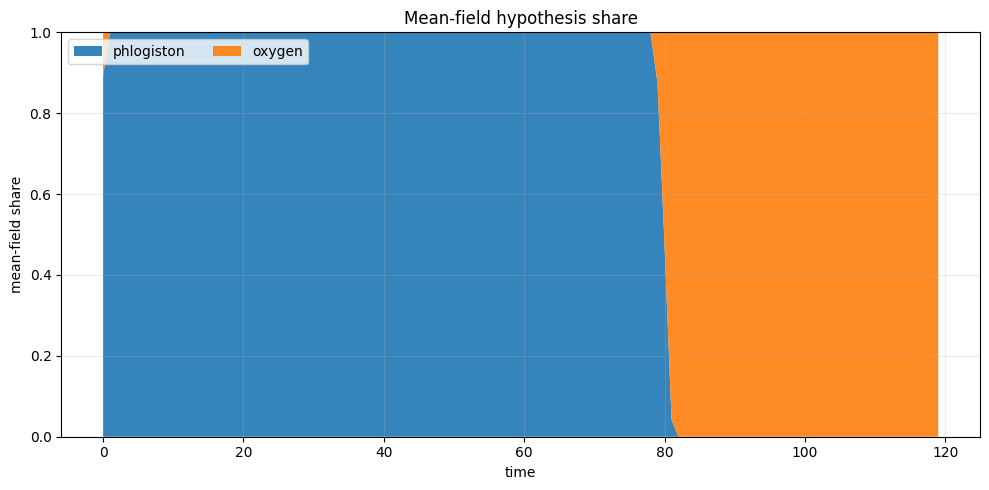

final oxygen share = 1.00


In [3]:
state = S.init_state(cfg, KEY)
idx_t = np.asarray(S.run_trace_index(cfg, state))            # (T, N) oxygen index per agent
winner_tn = (idx_t > 0.5).astype(int)                        # 0 = phlogiston, 1 = oxygen
out = plot.plot_mean_field_hypothesis_share(winner_tn=winner_tn,
        hypothesis_names=['phlogiston', 'oxygen'],
        save_path=RESULTS / 'mean_field_hypothesis_share.png')
plt.show()
print(f'final oxygen share = {winner_tn[-1].mean():.2f}')

## 3 — The paradigm as an evolving network (Bayes-net snapshots)

The structural heart. We take the full per-agent net trajectory and render the
population-mean paradigm net at four times: nodes coloured by their belief (the mass-law
nodes flip sign as the world reveals oxygen), edges drawn where the precision coupling is
present. On the **relational** substrate the belt couplings *grow over time* — the structure
is being learned, not just the node values.

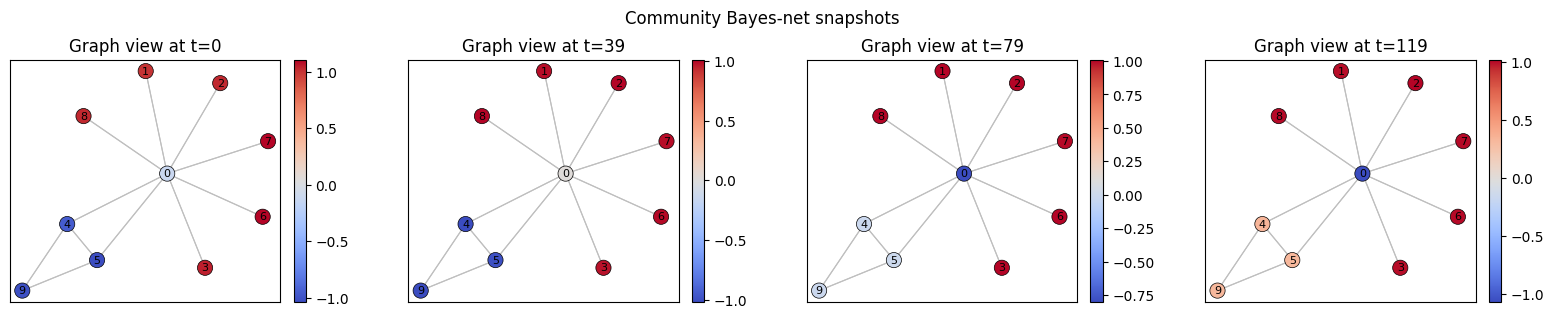

node order (0 = hidden phlogiston hub):
   0 phlogiston
   1 combustion_releases
   2 calcination_releases
   3 metal_is_calx_plus_phlog
   4 mass_change_sign
   5 gas_consumed
   6 air_has_capacity
   7 reduction_with_charcoal
   8 respiration_like_combustion
   9 calx_heavier_than_metal


In [4]:
Pi_t, h_t = S.run_trace_net(cfg, state)                      # (T,N,d,d), (T,N,d)
# colour nodes by the posterior MEAN mu = Pi^{-1} h (a stable belief scale), not the raw
# potential h (which grows without bound as precision accumulates). graph_only uses the
# passed h_t slot purely for node colour, so feeding the means is exactly what we want.
mu_t = np.stack([np.asarray(obs.population_means(Pi_t[t], h_t[t]))
                 for t in range(cfg.n_steps)])               # (T, N, d)
out = plot.plot_community_bayesnet_snapshots(
        np.asarray(Pi_t), mu_t, graph_only=True, max_snapshots=4,
        edge_threshold=0.15, layout_seed=3,
        save_path=RESULTS / 'community_bayesnet_snapshots.png')
plt.show()
print('node order (0 = hidden phlogiston hub):')
for i, n in enumerate(cfg.node_names):
    print(f'  {i:2d} {n}')

## 4 — Edge-edit timeline: expansion and reduction

The structure-learning activity. `shells.edge_count_trace` counts the present couplings of the
population-mean net over time: the relational data **expand** the net (the belt mass-balance
edges appear, so the count rises after the regime flip). Below we also run the **reduction**
move — BMR scores whether the data still support the phlogiston hub couplings — to show the
closed-form prune decision that complements the data-driven expansion.

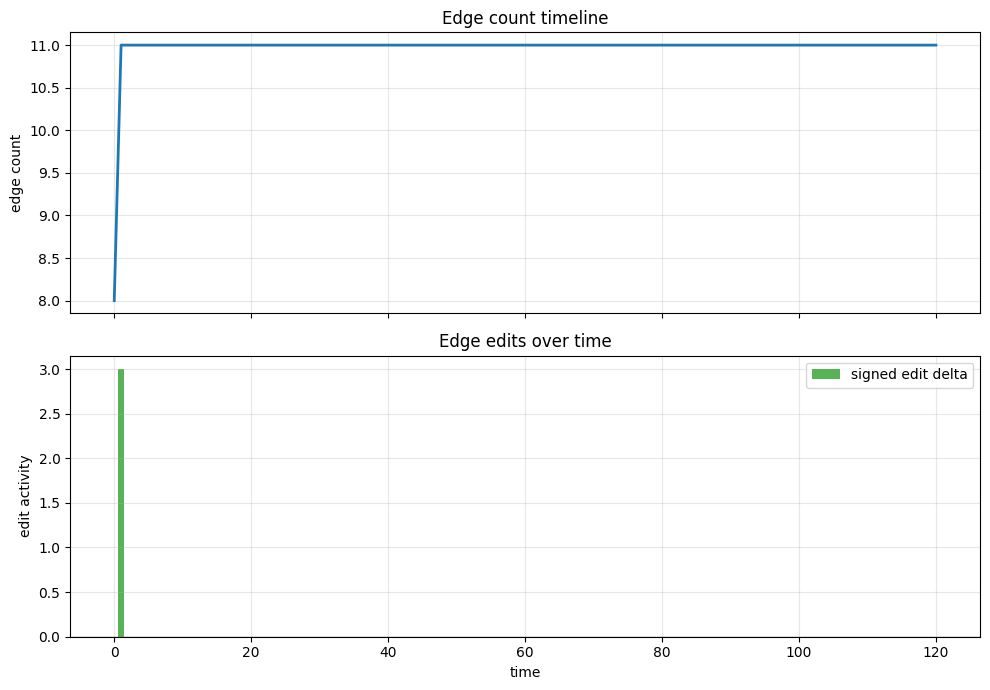

edge count: 8 (prior: hub star only) -> 11 (learned)  [+3 belt couplings wired in by the relational data = EXPANSION]
  BMR prune phlogiston–mass_change_sign: ΔF = -0.3  KEEP (data hold it)
  BMR prune phlogiston–combustion_releases: ΔF = -0.7  KEEP (data hold it)


In [5]:
from src.structural.belief import GaussianBeliefNet
counts, delta = shells.edge_count_trace(np.asarray(Pi_t), threshold=0.15)
# prepend the PRIOR net (before any data) so the data-driven EXPANSION is visible: the
# relational mass-balance experiment wires in the belt couplings on contact with the world.
d = len(cfg.node_names)
prior_Pi = np.abs(np.asarray(ph.phlogiston_prior(cfg).Pi))
prior_count = float((prior_Pi[np.triu_indices(d, 1)] > 0.15).sum())
counts = np.concatenate([[prior_count], counts])
delta = np.concatenate([[0.0], np.diff(counts)])
out = plot.plot_edge_edit_timeline(edge_count_t=counts, edge_edit_delta_t=delta,
                                   save_path=RESULTS / 'edge_edit_timeline.png')
plt.show()
print(f'edge count: {prior_count:.0f} (prior: hub star only) -> {counts[-1]:.0f} (learned)  '
      f'[+{counts[-1]-prior_count:.0f} belt couplings wired in by the relational data = EXPANSION]')

# REDUCTION move: does BMR still support the phlogiston hub edges given the accumulated data?
from src.structural.belief import GaussianBeliefNet
prior = ph.phlogiston_prior(cfg)
Pi_fin = np.asarray(Pi_t[-1]).mean(axis=0); h_fin = np.asarray(h_t[-1]).mean(axis=0)
post = GaussianBeliefNet(Pi=Pi_fin, h=h_fin, names=cfg.node_names)
for edge in [('phlogiston', 'mass_change_sign'), ('phlogiston', 'combustion_releases')]:
    reduced_prior = bmr.prune_edge_prior(prior, edge=edge)
    dF = float(bmr.bmr_prune(post, prior, reduced_prior)['delta_F'])
    verdict = 'PRUNE (data content without it)' if dF > 0 else 'KEEP (data hold it)'
    print(f'  BMR prune {edge[0]}–{edge[1]}: ΔF = {dF:+.1f}  {verdict}')

## 5 — Community-distance heatmap

Four belief communities (an SBM block each) holding a spread of starting convictions, now in
the **lock-in regime** (high γ) on **isolated** blocks (no bridges) — so each community keeps
its own paradigm rather than all converging. The heatmap is the distance between the
communities' mean *beliefs* at the end: which blocs ended aligned and which stayed apart — the
residual structural disagreement of a fragmented, locked-in field.

(The distance is on the posterior **mean** μ, not the precision Π: Π evolves identically for
every agent — the Fisher deposits do not depend on what an agent believes — so only the mean
carries the disagreement.)

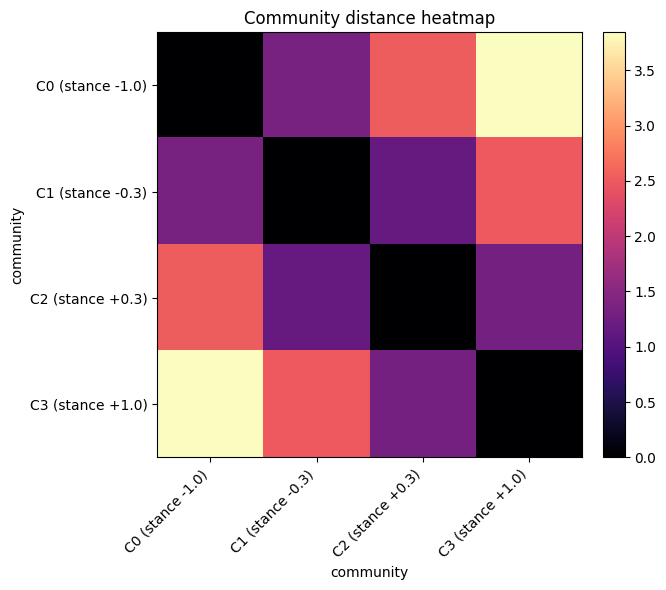

inter-community belief distances (‖μ_i − μ_j‖):
[[0.   1.35 2.53 3.84]
 [1.35 0.   1.18 2.49]
 [2.53 1.18 0.   1.32]
 [3.84 2.49 1.32 0.  ]]
=> locked, isolated communities stay structurally apart by their starting conviction.


In [6]:
# isolated, gamma-locked communities so they stay distinct (else everyone converges to truth)
cfg_c = dataclasses.replace(cfg, n_agents=120, core_governance=400.0)
from src.structural import graphs as G
graph_c = G.community([30, 30, 30, 30], intra=0.3, inter=0.0)   # isolated blocks (no bridge)
sizes = [30, 30, 30, 30]
stances = [-1.0, -0.3, 0.3, 1.0]                               # phlogiston pole -> oxygen pole
groups = [{"count": s, "paradigm": "phlogiston", "stance": st} for s, st in zip(sizes, stances)]
st_c = S.init_state(cfg_c, KEY, groups=groups, W_override=graph_c.trust_W())
Pi_c, h_c = S.run_trace_net(cfg_c, st_c)
mu_fin = np.asarray(obs.population_means(Pi_c[-1], h_c[-1]))    # (N, d) posterior means
bounds = np.cumsum([0] + sizes)
comm_mu = np.stack([mu_fin[bounds[k]:bounds[k+1]].mean(0) for k in range(4)])   # (4, d)
D = np.linalg.norm(comm_mu[:, None, :] - comm_mu[None, :, :], axis=2)            # (4,4)
out = plot.plot_community_distance_heatmap(
        D, community_labels=[f'C{k} (stance {s:+.1f})' for k, s in enumerate(stances)],
        save_path=RESULTS / 'community_distance_heatmap.png')
plt.show()
print('inter-community belief distances (‖μ_i − μ_j‖):')
print(np.round(D, 2))
print('=> locked, isolated communities stay structurally apart by their starting conviction.')

## Verdict

The principled structural model produces the paper's full figure language directly
(`src/structural/plot.py`), saved to `results/structural_paradigm_shift_relational/`:

* the **log-evidence race** shows the paradigm shift as the evidence envelope crossing;
* the **mean-field share** shows the population converting;
* the **Bayes-net snapshots** show the paradigm *as a network* reorganizing — on the
  relational substrate the belt couplings are *learned*, the structural signature the scalar
  models cannot draw;
* the **edge-edit timeline** counts that structure learning (expansion as the data add belt
  couplings; the BMR cells show the closed-form reduction decision on the hub edges);
* the **community-distance heatmap** shows which belief blocs ended structurally aligned.

This is the active-inference structure-learning model rendered in exactly the output style the
project wants, on the corrected (edge-moving) substrate — the same five views the old ad-hoc
landscape scaffold produced, now earned by the first-principles dynamics.